In [1]:
# ライブラリのインポート
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# データ読み込み
titanic = sns.load_dataset('titanic')

# 前処理（STEP3の内容を再実行）
drop_columns = ['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male']
df = titanic.drop(columns=drop_columns)
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df = pd.get_dummies(df, columns=['embarked'], prefix='embarked', dtype=int)
df['alone'] = df['alone'].astype(int)

# 特徴量とターゲットを分離
X = df.drop('survived', axis=1)
y = df['survived']

# データ分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ データ準備完了")
print(f"訓練データ: {X_train.shape[0]} 件")
print(f"テストデータ: {X_test.shape[0]} 件")
print(f"特徴量: {list(X.columns)}")

✅ データ準備完了
訓練データ: 712 件
テストデータ: 179 件
特徴量: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'embarked_C', 'embarked_Q', 'embarked_S']


In [2]:
# 前回の結果をベースラインとして再確認
print("📊 ベースライン（前回の結果）:")
print("=" * 60)

# ロジスティック回帰
lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_base.fit(X_train, y_train)
lr_base_pred = lr_base.predict(X_test)
lr_base_acc = accuracy_score(y_test, lr_base_pred)

# ランダムフォレスト
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)
rf_base_pred = rf_base.predict(X_test)
rf_base_acc = accuracy_score(y_test, rf_base_pred)

print(f"  ロジスティック回帰:  {lr_base_acc*100:.1f}%")
print(f"  ランダムフォレスト:  {rf_base_acc*100:.1f}%")
print(f"\nこれを超えることが目標です！")

📊 ベースライン（前回の結果）:
  ロジスティック回帰:  79.9%
  ランダムフォレスト:  82.1%

これを超えることが目標です！


In [3]:
# 改善1：新しい特徴量を追加する
# 既存のデータを組み合わせて、予測に役立つ新しい情報を作る

print("🔧 改善1：特徴量エンジニアリング")
print("=" * 60)

# 家族の人数（sibsp + parch + 自分1人）
# なぜ？ → 家族が多い/少ないで生存率が変わる可能性がある
X_train_v2 = X_train.copy()
X_test_v2 = X_test.copy()

X_train_v2['family_size'] = X_train_v2['sibsp'] + X_train_v2['parch'] + 1
X_test_v2['family_size'] = X_test_v2['sibsp'] + X_test_v2['parch'] + 1

# 一人当たりの運賃（fare / family_size）
# なぜ？ → 運賃は家族分まとめて購入している場合がある
X_train_v2['fare_per_person'] = X_train_v2['fare'] / X_train_v2['family_size']
X_test_v2['fare_per_person'] = X_test_v2['fare'] / X_test_v2['family_size']

# 子供かどうか（age < 15）
# なぜ？ → 子供は優先的に救助された傾向がある
X_train_v2['is_child'] = (X_train_v2['age'] < 15).astype(int)
X_test_v2['is_child'] = (X_test_v2['age'] < 15).astype(int)

print("追加した特徴量:")
print("  family_size:    家族の人数（兄弟配偶者 + 親子 + 自分）")
print("  fare_per_person: 一人当たりの運賃")
print("  is_child:       子供かどうか（15歳未満=1）")
print(f"\n特徴量の数: {X_train.shape[1]} → {X_train_v2.shape[1]}（3つ追加）")
print(f"特徴量一覧: {list(X_train_v2.columns)}")

🔧 改善1：特徴量エンジニアリング
追加した特徴量:
  family_size:    家族の人数（兄弟配偶者 + 親子 + 自分）
  fare_per_person: 一人当たりの運賃
  is_child:       子供かどうか（15歳未満=1）

特徴量の数: 10 → 13（3つ追加）
特徴量一覧: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone', 'embarked_C', 'embarked_Q', 'embarked_S', 'family_size', 'fare_per_person', 'is_child']


In [4]:
# 新しい特徴量でモデルを再学習
print("📈 新しい特徴量での結果:")
print("=" * 60)

# ロジスティック回帰
lr_v2 = LogisticRegression(max_iter=1000, random_state=42)
lr_v2.fit(X_train_v2, y_train)
lr_v2_pred = lr_v2.predict(X_test_v2)
lr_v2_acc = accuracy_score(y_test, lr_v2_pred)

# ランダムフォレスト
rf_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_v2.fit(X_train_v2, y_train)
rf_v2_pred = rf_v2.predict(X_test_v2)
rf_v2_acc = accuracy_score(y_test, rf_v2_pred)

print(f"ロジスティック回帰:  {lr_base_acc*100:.1f}% → {lr_v2_acc*100:.1f}%", end="")
print(f"  {'⬆️ 改善!' if lr_v2_acc > lr_base_acc else '⬇️ 悪化' if lr_v2_acc < lr_base_acc else '→ 変化なし'}")

print(f"ランダムフォレスト:  {rf_base_acc*100:.1f}% → {rf_v2_acc*100:.1f}%", end="")
print(f"  {'⬆️ 改善!' if rf_v2_acc > rf_base_acc else '⬇️ 悪化' if rf_v2_acc < rf_base_acc else '→ 変化なし'}")

📈 新しい特徴量での結果:
ロジスティック回帰:  79.9% → 80.4%  ⬆️ 改善!
ランダムフォレスト:  82.1% → 81.6%  ⬇️ 悪化


## 📖 学習メモ：GridSearchCV とは？

### 概要
GridSearchCV は scikit-learn の**ハイパーパラメータ自動探索**ツール。
いろいろなパラメータの組み合わせを自動的に試して、最も良い結果を出すパラメータを見つけてくれる。

### なぜ必要？
- 機械学習モデルには「ハイパーパラメータ」という設定値がある
- 例：ランダムフォレストの「木の数」「木の深さ」など
- これらの最適な値は、データによって異なる
- 手動で1つずつ試すのは非効率 → GridSearchCVが自動で探索

### 仕組み
1. パラメータの候補リストを渡す
2. すべての組み合わせを試す（グリッド = 格子状に全探索）
3. 交差検証（CV = Cross Validation）で各組み合わせを評価
4. 最もスコアが高い組み合わせを返す

### 交差検証（Cross Validation）とは？
- データを5分割して、4つで学習・1つでテストを5回繰り返す
- 1回だけのテストより信頼性の高い評価ができる
- 「たまたま良い結果」を防ぐ

### 用語
| 用語 | 意味 |
|------|------|
| ハイパーパラメータ | モデルの設定値（人間が決める） |
| GridSearch | すべての組み合わせを試す探索方法 |
| CV（Cross Validation） | 交差検証（データを分割して複数回評価） |
| n_estimators | ランダムフォレストの木の数 |
| max_depth | 木の深さの上限 |
| min_samples_split | ノードを分割する最小サンプル数 |
| min_samples_leaf | 葉ノードの最小サンプル数 |

In [5]:
# 改善2：ハイパーパラメータの調整
# GridSearchCVで最適なパラメータを自動探索する
from sklearn.model_selection import GridSearchCV

print("🔍 改善2：ハイパーパラメータの自動探索（GridSearchCV）")
print("=" * 60)
print("探索中... しばらくお待ちください ⏳\n")

# ランダムフォレストのパラメータ候補
param_grid = {
    'n_estimators': [50, 100, 200],      # 木の数
    'max_depth': [3, 5, 7, 10, None],    # 木の深さ
    'min_samples_split': [2, 5, 10],     # 分割に必要な最小サンプル数
    'min_samples_leaf': [1, 2, 4]        # 葉に必要な最小サンプル数
}

# GridSearchCV（5分割交差検証で最適パラメータを探索）
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,              # 5分割交差検証
    scoring='accuracy', # 正解率で評価
    n_jobs=-1,         # 全CPUを使用して高速化
    verbose=0
)

# 新しい特徴量のデータで探索
grid_search.fit(X_train_v2, y_train)

print(f"✅ 探索完了！")
print(f"\n最適なパラメータ:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n交差検証での最高スコア: {grid_search.best_score_*100:.1f}%")

🔍 改善2：ハイパーパラメータの自動探索（GridSearchCV）
探索中... しばらくお待ちください ⏳

✅ 探索完了！

最適なパラメータ:
  max_depth: 7
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 50

交差検証での最高スコア: 82.3%


c:\dev\titanic-ml-project\venv\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [6]:
# 最適なパラメータで最終モデルを構築
print("🏆 最適パラメータで最終モデルを構築:")
print("=" * 60)

# GridSearchCVが見つけた最適モデルを使用
best_model = grid_search.best_estimator_

# テストデータで予測
best_pred = best_model.predict(X_test_v2)
best_acc = accuracy_score(y_test, best_pred)

print(f"\n最終モデルの正解率: {best_acc*100:.1f}%")

# 全モデルの比較
print(f"\n📊 全モデル比較:")
print("=" * 60)
results = {
    'ロジスティック回帰（ベース）': lr_base_acc,
    'ランダムフォレスト（ベース）': rf_base_acc,
    'ロジスティック回帰（特徴量追加）': lr_v2_acc,
    'ランダムフォレスト（特徴量追加）': rf_v2_acc,
    'ランダムフォレスト（最適化済み）': best_acc
}

for name, acc in results.items():
    bar = '█' * int(acc * 50)
    print(f"  {name:<35} | {acc*100:.1f}% | {bar}")

🏆 最適パラメータで最終モデルを構築:

最終モデルの正解率: 83.8%

📊 全モデル比較:
  ロジスティック回帰（ベース）                      | 79.9% | ███████████████████████████████████████
  ランダムフォレスト（ベース）                      | 82.1% | █████████████████████████████████████████
  ロジスティック回帰（特徴量追加）                    | 80.4% | ████████████████████████████████████████
  ランダムフォレスト（特徴量追加）                    | 81.6% | ████████████████████████████████████████
  ランダムフォレスト（最適化済み）                    | 83.8% | █████████████████████████████████████████


特徴量の重要度とは？
→ モデルが予測する時に、どの情報をどれだけ重視したかを示します。
　値が大きいほど、その特徴量が予測に大きく貢献しています。

In [7]:
# 最終モデルの詳細評価
print("📋 最終モデルの詳細評価:")
print("=" * 60)
print(classification_report(y_test, best_pred, target_names=['Dead', 'Survived']))

# 特徴量の重要度を確認
print("🔍 特徴量の重要度（どの情報が予測に役立ったか）:")
print("=" * 60)

importances = best_model.feature_importances_
feature_importance = pd.DataFrame({
    'feature': X_train_v2.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

for _, row in feature_importance.iterrows():
    bar = '█' * int(row['importance'] * 50)
    print(f"  {row['feature']:<20} | {row['importance']:.4f} | {bar}")

📋 最終モデルの詳細評価:
              precision    recall  f1-score   support

        Dead       0.83      0.91      0.87       105
    Survived       0.86      0.73      0.79        74

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179

🔍 特徴量の重要度（どの情報が予測に役立ったか）:
  sex                  | 0.3507 | █████████████████
  fare                 | 0.1517 | ███████
  fare_per_person      | 0.1323 | ██████
  age                  | 0.1091 | █████
  pclass               | 0.0833 | ████
  family_size          | 0.0576 | ██
  sibsp                | 0.0269 | █
  is_child             | 0.0209 | █
  parch                | 0.0186 | 
  embarked_S           | 0.0165 | 
  embarked_C           | 0.0148 | 
  alone                | 0.0111 | 
  embarked_Q           | 0.0067 | 


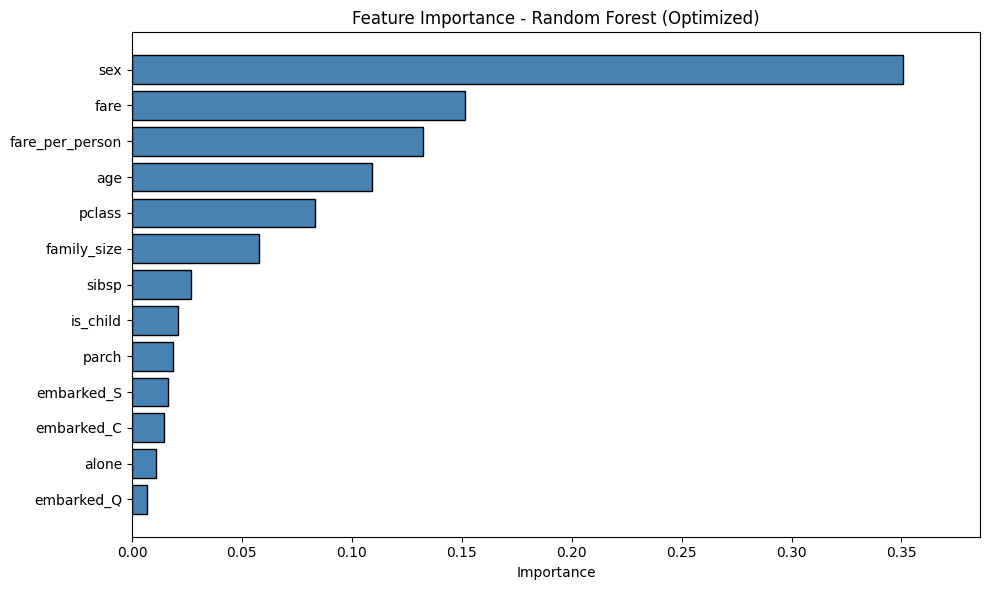

✅ グラフを outputs/ フォルダに保存しました


In [8]:
# 特徴量重要度のグラフ
fig, ax = plt.subplots(figsize=(10, 6))

feature_importance_sorted = feature_importance.sort_values('importance', ascending=True)

ax.barh(
    feature_importance_sorted['feature'],
    feature_importance_sorted['importance'],
    color='steelblue',
    edgecolor='black'
)
ax.set_xlabel('Importance')
ax.set_title('Feature Importance - Random Forest (Optimized)')
ax.set_xlim(0, max(importances) * 1.1)

plt.tight_layout()
plt.savefig('../outputs/feature_importance.png')
plt.show()

print("✅ グラフを outputs/ フォルダに保存しました")

特徴量の重要度グラフから重要な発見があります：

グラフの読み取り
順位	特徴量	意味
🥇 1位	sex	性別が最も重要（女性が優先的に救助された）
🥈 2位	fare	運賃（高い運賃 = 上流クラス = 生存率高い）
🥉 3位	fare_per_person	一人当たりの運賃（今回追加した特徴量！）
4位	age	年齢（子供は生存率が高い）
5位	pclass	チケットクラス
ポイント： 今回追加した fare_per_person が3位に入っています！
特徴量エンジニアリングが効果的だったことがわかります。

In [9]:
# プロジェクト全体の最終まとめ
print("🚢 タイタニック生存予測 - 最終まとめ")
print("=" * 60)

print("\n【1. データ概要】")
print(f"  データ件数: 891人")
print(f"  生存率: 38.4%")
print(f"  使用した特徴量: {X_train_v2.shape[1]}個")

print("\n【2. モデル比較結果】")
print("-" * 60)
print(f"  {'モデル':<35} {'正解率':>8}")
print("-" * 60)
for name, acc in results.items():
    marker = " ← 最終モデル" if name == 'ランダムフォレスト（最適化済み）' else ""
    print(f"  {name:<35} {acc*100:.1f}%{marker}")

print(f"\n【3. 最終モデルの詳細】")
print(f"  アルゴリズム: ランダムフォレスト")
print(f"  最適パラメータ:")
for param, value in grid_search.best_params_.items():
    print(f"    {param}: {value}")

print(f"\n【4. 特徴量の重要度TOP5】")
for i, (_, row) in enumerate(feature_importance.head(5).iterrows()):
    medals = ['🥇', '🥈', '🥉', '4️⃣', '5️⃣']
    print(f"  {medals[i]} {row['feature']}: {row['importance']:.4f}")

print(f"\n【5. 改善の効果】")
print(f"  ベースライン（ランダムフォレスト）: {rf_base_acc*100:.1f}%")
print(f"  最終モデル: {best_acc*100:.1f}%")
improvement = (best_acc - rf_base_acc) * 100
if improvement > 0:
    print(f"  改善幅: +{improvement:.1f}%")
elif improvement == 0:
    print(f"  改善幅: 変化なし（ベースラインが既に最適に近い）")
else:
    print(f"  改善幅: {improvement:.1f}%")

print("\n✅ プロジェクト完了！")

🚢 タイタニック生存予測 - 最終まとめ

【1. データ概要】
  データ件数: 891人
  生存率: 38.4%
  使用した特徴量: 13個

【2. モデル比較結果】
------------------------------------------------------------
  モデル                                      正解率
------------------------------------------------------------
  ロジスティック回帰（ベース）                      79.9%
  ランダムフォレスト（ベース）                      82.1%
  ロジスティック回帰（特徴量追加）                    80.4%
  ランダムフォレスト（特徴量追加）                    81.6%
  ランダムフォレスト（最適化済み）                    83.8% ← 最終モデル

【3. 最終モデルの詳細】
  アルゴリズム: ランダムフォレスト
  最適パラメータ:
    max_depth: 7
    min_samples_leaf: 1
    min_samples_split: 2
    n_estimators: 50

【4. 特徴量の重要度TOP5】
  🥇 sex: 0.3507
  🥈 fare: 0.1517
  🥉 fare_per_person: 0.1323
  4️⃣ age: 0.1091
  5️⃣ pclass: 0.0833

【5. 改善の効果】
  ベースライン（ランダムフォレスト）: 82.1%
  最終モデル: 83.8%
  改善幅: +1.7%

✅ プロジェクト完了！


## 🚢 タイタニック生存予測 - 最終まとめ

### 1. データ概要
- データ件数: 891人
- 生存率: 38.4%
- 使用した特徴量: 13個

### 2. モデル比較結果

| モデル | 正解率 |
|--------|--------|
| ロジスティック回帰（ベース） | 79.9% |
| ランダムフォレスト（ベース） | 82.1% |
| ロジスティック回帰（特徴量追加） | 80.4% |
| ランダムフォレスト（特徴量追加） | 81.6% |
| **ランダムフォレスト（最適化済み）** | **83.8%** ← 最終モデル |

### 3. 最終モデルの詳細
- **アルゴリズム**: ランダムフォレスト
- **最適パラメータ**（GridSearchCVで自動探索）:
  - max_depth: 7
  - min_samples_leaf: 1
  - min_samples_split: 2
  - n_estimators: 50

### 4. 特徴量の重要度 TOP5

| 順位 | 特徴量 | 重要度 | 説明 |
|------|--------|--------|------|
| 🥇 1位 | sex | 最も重要 | 性別（女性が優先的に救助された） |
| 🥈 2位 | fare | 高い | 運賃（上流クラスほど生存率が高い） |
| 🥉 3位 | fare_per_person | 高い | 一人当たりの運賃（追加した特徴量） |
| 4位 | age | 中程度 | 年齢（子供は生存率が高い） |
| 5位 | pclass | 中程度 | チケットクラス |

### 5. 改善の効果
- ベースライン（ランダムフォレスト）: 82.1%
- 最終モデル: 83.8%
- **改善幅: +1.7%**

### 6. 改善で実施したこと
1. **特徴量エンジニアリング**: 新しい特徴量を3つ追加
   - family_size（家族の人数）
   - fare_per_person（一人当たりの運賃）
   - is_child（子供かどうか）
2. **ハイパーパラメータ調整**: GridSearchCVで最適パラメータを自動探索

### 7. 学んだこと
- データの前処理（欠損値補完・エンコーディング）が重要
- 特徴量エンジニアリングでモデルの精度を改善できる
- GridSearchCVでハイパーパラメータの最適化を自動化できる
- 正解率だけでなく、Precision/Recall/F1で多角的に評価する必要がある
- 性別・運賃・年齢が生存予測に最も重要な要素だった